# 15.3.1 连续右端、求解器与前向灵敏度

## 学习目标与先修知识

区分连续模型（model）、离散求解程序和两者各自的参数（parameter）导数（derivative）。

先修：2.4 Euler 误差；15.2 离散转移；链式法则（chain rule）。

## 具体问题

将清除率 k 放进连续方程，再用 Euler 积分。自动微分（automatic differentiation，AD）穿过 Euler 程序得到的梯度（gradient），是否与连续方程的解析梯度在有限步长完全相同？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型对照。

In [2]:
x0,k,T,h=2.,.7,2.,.2;print("连续终点：",x0*np.exp(-k*T));print("Euler 终点：",x0*(1-k*h)**round(T/h))

连续终点： 0.493193927883213
Euler 终点： 0.44260315777606135


## 模型假设

标量右端 $f(x,k)=-kx$，$k>0$ 的单位为 1/T；初态固定，观测（observation）时刻固定。第一轮使用线性右端充当可微网络可表达的已知子类，先独立核验求解及求导，再扩展函数族。$h>0$ 且 $kh<1$ 保持此例 Euler 状态（state）非负。

## 数学解释与推导

连续解为 $x(t)=x_0e^{-kt}$，故连续灵敏度 $s(t)=\partial_kx(t)=-t x(t)$。由 $x'=f(x,k)$ 对 $k$ 求导得 $s'=f_xs+f_k=-ks-x$，$s(0)=0$。Euler 程序为 $x_{n+1}=(1-kh)x_n$，对这个程序求导得到 $s_{n+1}=(1-kh)s_n-hx_n$。两个梯度分别对应不同的前向计算，在有限步长一般不相等；缩小步长后比较收敛。神经常微分方程（neural ordinary differential equation，Neural ODE）只是把右端 $f$ 换成可学习的可微函数，不能省略求解误差检查。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def clearance_exact(x0, k, times):
    return [float(x0*math.exp(-k*t)) for t in times]


def euler_forward_sensitivity(x0, k, h, steps):
    """Return state and dx/dk for the *discretized* Euler program."""
    states, sensitivity = [float(x0)], [0.]
    for _ in range(steps):
        x, s = states[-1], sensitivity[-1]
        states.append((1-k*h)*x)
        sensitivity.append((1-k*h)*s-h*x)
    return states, sensitivity

## 对照实验

改变已声明的条件并比较曲线与数值。

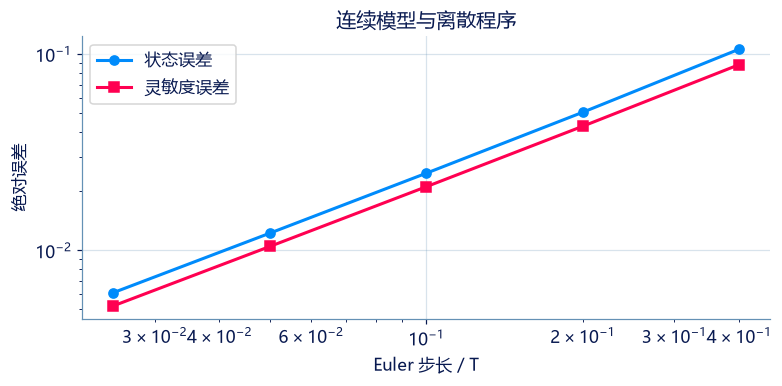

In [4]:
x0,k,T=2.,.7,2.;hs=[.4,.2,.1,.05,.025];state_error=[];gradient_error=[]
for h in hs:
    state,sens=euler_forward_sensitivity(x0,k,h,round(T/h));state_error.append(abs(state[-1]-x0*np.exp(-k*T)));gradient_error.append(abs(sens[-1]+T*x0*np.exp(-k*T)))
fig,ax=plt.subplots(figsize=(7,3.4));ax.loglog(hs,state_error,"o-",label="状态误差",color=BLUE);ax.loglog(hs,gradient_error,"s-",label="灵敏度误差",color=PINK);ax.set(xlabel="Euler 步长 / T",ylabel="绝对误差",title="连续模型与离散程序");ax.legend();ax.grid(alpha=.25);plt.show()

## 结果解释

两种误差都随网格细化减小。梯度检查应先说清是检查离散程序还是连续方程；只在某一个粗步长吻合，不能替代收敛证据。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
for h in [.4,.2,.1]:
    states,sens=euler_forward_sensitivity(2.,.7,h,round(2/h));factor=(1-.7*h);n=round(2/h)
    np.testing.assert_allclose(states[-1],2*factor**n)
    np.testing.assert_allclose(sens[-1],-2*n*h*factor**(n-1))
assert state_error[-1]<state_error[0] and gradient_error[-1]<gradient_error[0]
print("离散闭式导数与细化趋势核验通过。")

离散闭式导数与细化趋势核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：连续与离散梯度

固定 Euler 步长 h 时，穿过求解程序的自动微分（automatic differentiation，AD）梯度（gradient）是什么？

- **A.** 该离散程序的参数（parameter）梯度；与连续目标梯度一般有步长误差。
- **B.** 必定是连续方程的精确梯度。
- **C.** 完全不依赖 h。
- **D.** 只能通过 Monte Carlo 得到。

[作答：连续与离散梯度](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-two-gradients)

### 第 2 题 · 单项选择题：固定初态的灵敏度

x(0)=x0 与 k 无关时，s=∂x/∂k 的初值（initial condition）是什么？

- **A.** x0。
- **B.** 0。
- **C.** -k x0。
- **D.** 无法定义。

[作答：固定初态的灵敏度](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-sensitivity-initial)

### 第 3 题 · Python 计算题：连续清除的解析状态

给定固定初态、正清除率与观测（observation）时刻，返回各时刻状态（state）。

**函数与代码模板**

```python
def solve(
    x0: float,
    k: float,
    times: list[float],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 固定初态。 | U |
| `k` | `float` | 清除率。 | 1/T |
| `times` | `list[float]` | 非负观测时刻。 | T |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 各观测时刻的解析总量。 | U |

**计算规则**

对每个 t 返回 x0*exp(-k*t)。

**约束与边界**

- x0≥0，k≥0，时刻非负且不超过 100 T。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 固定初态。 | 2 | U |
| k | 清除率。 | 0 | 1/T |
| times | 非负观测时刻。 | [0.0, 1.0, 2.0] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 2.0
k = 0.0
times = [0.0, 1.0, 2.0]

result = solve(x0, k, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 各观测时刻的解析总量。 | [2.0, 2.0, 2.0] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0, 2.0, 2.0]
```

**样例解释**

k=0 时所有时刻保持初态。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：连续清除的解析状态](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-exact-decay)

### 第 4 题 · Python 计算题：Euler 状态与参数灵敏度

同时推进 x 和 dx/dk，返回包含初态的两条路径。

**函数与代码模板**

```python
def solve(
    x0: float,
    k: float,
    h: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 固定初态。 | U |
| `k` | `float` | 清除率。 | 1/T |
| `h` | `float` | 固定步长。 | T |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

按以下顺序返回元组：(states, sensitivity)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | Euler 状态（state）路径。 | U |
| `sensitivity` | `list[float]` | 每步对 k 的导数（derivative）。 | U·T |

**计算规则**

初始 s=0；每步 x_new=(1-k*h)*x，s_new=(1-k*h)*s-h*x；返回两条含初值（initial condition）路径。

**约束与边界**

- x0≥0，k≥0，h>0，0≤steps≤100 且 k*h<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 固定初态。 | 2 | U |
| k | 清除率。 | 0.5 | 1/T |
| h | 固定步长。 | 0.2 | T |
| steps | 更新次数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 2.0
k = 0.5
h = 0.2
steps = 2

result = solve(x0, k, h, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | Euler 状态（state）路径。 | [2.0, 1.8, 1.62] | U |
| sensitivity | 每步对 k 的导数（derivative）。 | [0.0, -0.4, -0.7200000000000001] | U·T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2.0, 1.8, 1.62],
                   [0.0, -0.4, -0.7200000000000001])
```

**样例解释**

初始灵敏度为0；一步更新为 (1-kh)s-hx。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：Euler 状态与参数灵敏度](http://127.0.0.1:8000/chapters/15-03-%E7%A5%9E%E7%BB%8F%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p15-euler-sensitivity)

**进一步阅读**

[Chen 等的 Neural ODE 原论文](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)；本节采用可解析标量基准。